## Day 3 : Student Exam Score Prediction using Polynomial Regression 🎓📈

## 1. Load the Datasets

In [31]:
# import library
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("/data/student_performance.csv")

## 2. Understand the Dataset

In [4]:
# check the 5 row
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [6]:
# checking Duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# check whether student_id nunique
print("Unique student IDs :",df['student_id'].nunique())

Unique student IDs : 1000000


In [8]:
# understand the numerical data
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278933,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


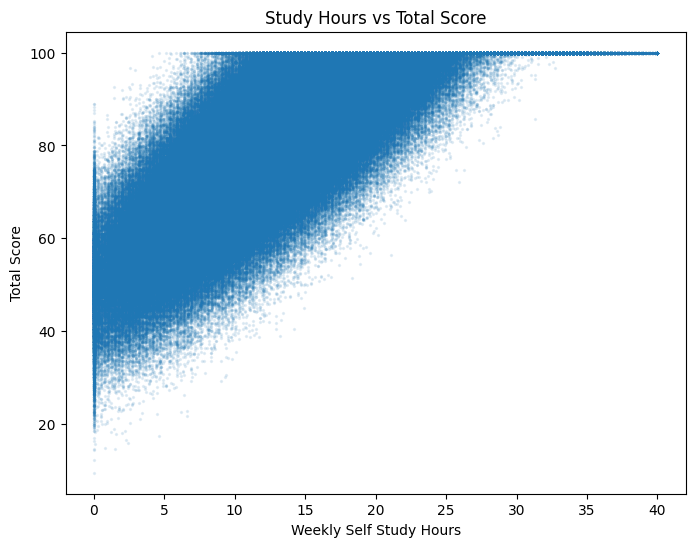

In [10]:
# visualize the relationship

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['weekly_self_study_hours'],
    df['total_score'],
    s=2,
    alpha=0.1
)

plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")
plt.title("Study Hours vs Total Score")
plt.show()

In [11]:
# select x for feature and y for target

x=df[['weekly_self_study_hours']]
y=df['total_score']

In [12]:
x.head()

,weekly_self_study_hours
0,18.5
1,14.0
2,19.5
3,25.7
4,13.4


In [13]:
y.head()

,total_score
0,97.9
1,83.9
2,100.0
3,100.0
4,92.0


In [14]:
# train/test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# Check the size
print("x-train :",x_train.shape)
print("x-test :",x_test.shape)

x-train : (800000, 1)
x-test : (200000, 1)


In [18]:
print("y-train :",y_train.shape)
print("y-test :",y_test.shape)

y-train : (800000,)
y-test : (200000,)


In [19]:
# linear Regression Baseline
from sklearn.linear_model import LinearRegression

In [20]:
linear_model=LinearRegression()

In [21]:
linear_model.fit(x_train, y_train)

LinearRegression()

In [22]:
# make predictions

y_pred_linear = linear_model.predict(x_test)

In [33]:
results=pd.DataFrame({
  "Actual ":y_test.values,
  "Predicted ":y_pred_linear
})

print(results.head())


   Actual   Predicted 
0     53.9   64.056714
1     77.3   88.038713
2     75.0   72.777441
3     85.7   84.223395
4     30.8   58.606259


In [34]:
# Evaluate the baseline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [35]:
mae_linear =mean_absolute_error(y_test,y_pred_linear)
mse_linear =mean_squared_error(y_test,y_pred_linear)
rmse_linear =np.sqrt(mse_linear)
r2_linear =r2_score(y_test,y_pred_linear)

print("Linear Regression")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 7.161324064837911
MSE : 80.93499659297578
RMSE: 8.996387974791649
R²  : 0.6600435613904074


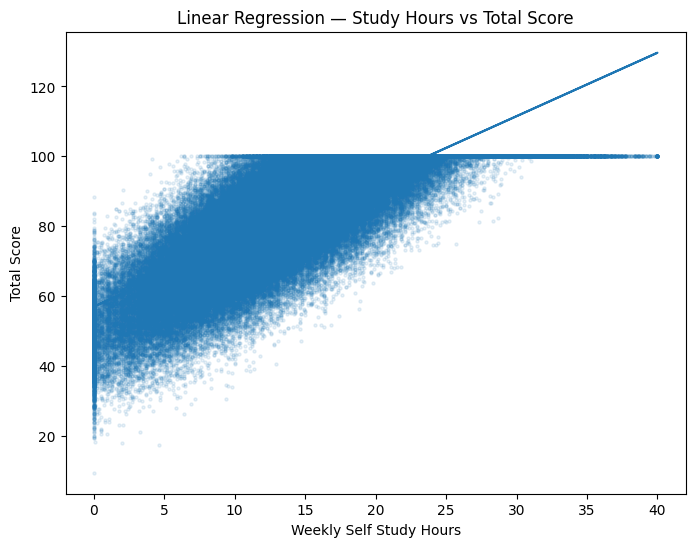

In [37]:
# visualize the line
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    x_test,
    y_test,
    s=5,
    alpha=0.1
)

plt.plot(
    x_test,
    y_pred_linear
)

plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")
plt.title("Linear Regression — Study Hours vs Total Score")

plt.show()

## Create Polynominal Feature

In [38]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2)

x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [41]:
print("Original shape :",x_train.shape)
print("Polynomial shape :",x_train_poly.shape)

Original shape : (800000, 1)
Polynomial shape : (800000, 3)


## Train Polynomial Regression

In [42]:
poly_model = LinearRegression()
poly_model.fit(x_train_poly,y_train)

LinearRegression()

In [43]:
y_pred_poly=poly_model.predict(x_test_poly)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_poly = mean_absolute_error(y_test, y_pred_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)

rmse_poly = np.sqrt(mse_poly)

r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

Polynomial Regression
MAE : 6.308662719972645
MSE : 68.39798359757813
RMSE: 8.27030734601672
R²  : 0.712703578294485


## Test Polynomial Degrees 1–5

In [47]:
results = []

for degree in range(1, 6):

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    # Train model
    model = LinearRegression()
    model.fit(x_train_poly, y_train)

    # Prediction
    y_pred = model.predict(x_test_poly)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([
        degree,
        mae,
        mse,
        rmse,
        r2
    ])

results

[[1,
  7.161324064837954,
  80.93499659297585,
  np.float64(8.996387974791652),
  0.6600435613904072],
 [2,
  6.308662719972645,
  68.39798359757813,
  np.float64(8.27030734601672),
  0.712703578294485],
 [3,
  6.212229185454245,
  67.68162906116561,
  np.float64(8.226884529465915),
  0.7157125280347976],
 [4,
  6.130179452261157,
  67.27550859493708,
  np.float64(8.202164872455143),
  0.7174183817835762],
 [5,
  6.107987336676097,
  67.22037975699372,
  np.float64(8.198803556433933),
  0.7176499429647815]]

In [48]:
results_df = pd.DataFrame(
    results,
    columns=["Degree", "MAE", "MSE", "RMSE", "R2"]
)

results_df

,Degree,MAE,MSE,RMSE,R2
0,1,7.161324,80.934997,8.996388,0.660044
1,2,6.308663,68.397984,8.270307,0.712704
2,3,6.212229,67.681629,8.226885,0.715713
3,4,6.130179,67.275509,8.202165,0.717418
4,5,6.107987,67.220380,8.198804,0.717650


## Visualize the Polynomial Curve

In [51]:
# Degree 5
poly_final = PolynomialFeatures(degree=5)

x_train_poly5 = poly_final.fit_transform(x_train)
x_test_poly5 = poly_final.transform(x_test)

# Train
final_model = LinearRegression()
final_model.fit(x_train_poly5, y_train)

LinearRegression()

In [52]:
x_curve = np.linspace(
    x["weekly_self_study_hours"].min(),
    x["weekly_self_study_hours"].max(),
    500
).reshape(-1, 1)

x_curve_poly = poly_final.transform(x_curve)

y_curve = final_model.predict(x_curve_poly)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


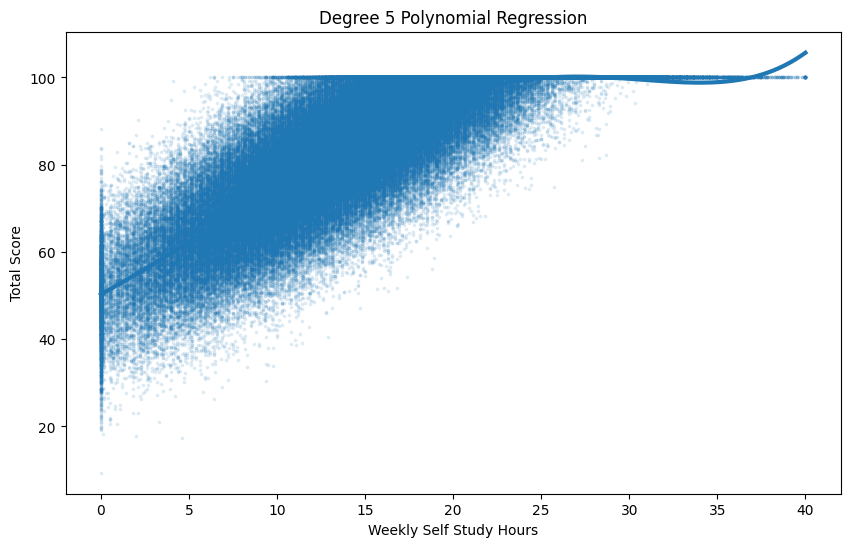

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x_test,
    y_test,
    s=3,
    alpha=0.1
)

plt.plot(
    x_curve,
    y_curve,
    linewidth=3
)

plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")
plt.title("Degree 5 Polynomial Regression")

plt.show()

## Predict New Student Scores

In [54]:
new_students = np.array([
    [5],
    [8],
    [10],
    [12],
    [15],
    [18],
    [20],
    [25],
    [30],
    [35]
])

In [55]:
new_students_poly = poly_final.transform(new_students)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [56]:
new_predictions = final_model.predict(new_students_poly)

print(new_predictions)

[62.24958584 69.93035328 75.07639738 80.08567119 87.01128582 92.78743696
 95.79171488 99.87692482 99.69983506 98.9189467 ]


In [57]:
prediction_df = pd.DataFrame({
    "Weekly Study Hours": new_students.flatten(),
    "Predicted Total Score": new_predictions
})

prediction_df

,Weekly Study Hours,Predicted Total Score
0,5,62.249586
1,8,69.930353
2,10,75.076397
3,12,80.085671
4,15,87.011286
5,18,92.787437
6,20,95.791715
7,25,99.876925
8,30,99.699835
9,35,98.918947


In [59]:
sample_students = df.sample(10, random_state=42)

x_new = sample_students[["weekly_self_study_hours"]]
actual_scores = sample_students["total_score"]

x_new_poly = poly_final.transform(x_new)

predicted_scores = final_model.predict(x_new_poly)

comparison_df = pd.DataFrame({
    "Study Hours": x_new["weekly_self_study_hours"].values,
    "Actual Score": actual_scores.values,
    "Predicted Score": predicted_scores
})

comparison_df["Error"] = (
    comparison_df["Actual Score"]
    - comparison_df["Predicted Score"]
).abs()

comparison_df

,Study Hours,Actual Score,Predicted Score,Error
0,3.9,53.9,59.505912,5.605912
1,17.1,77.3,91.202342,13.902342
2,8.7,75.0,71.737970,3.262030
3,15.0,85.7,87.011286,1.311286
4,0.9,30.8,52.328131,21.528131
5,3.8,62.3,59.259226,3.040774
6,4.1,74.0,60.000714,13.999286
7,4.2,68.9,60.248818,8.651182
8,15.5,83.7,88.066480,4.366480
9,12.5,95.5,81.298986,14.201014


In [60]:
mae_new = mean_absolute_error(
    comparison_df["Actual Score"],
    comparison_df["Predicted Score"]
)

print("MAE for these 10 students:", mae_new)

MAE for these 10 students: 8.986843542555862


## Final Model Evaluation

In [62]:
y_pred_final = final_model.predict(x_test_poly5)

mae_final = mean_absolute_error(y_test, y_pred_final)
mse_final = mean_squared_error(y_test, y_pred_final)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test, y_pred_final)

print("Final Polynomial Regression (Degree 5)")
print("--------------------------------------")
print("MAE :", mae_final)
print("MSE :", mse_final)
print("RMSE:", rmse_final)
print("R²  :", r2_final)

Final Polynomial Regression (Degree 5)
--------------------------------------
MAE : 6.107987336676097
MSE : 67.22037975699372
RMSE: 8.198803556433933
R²  : 0.7176499429647815


## Actual vs Predicted

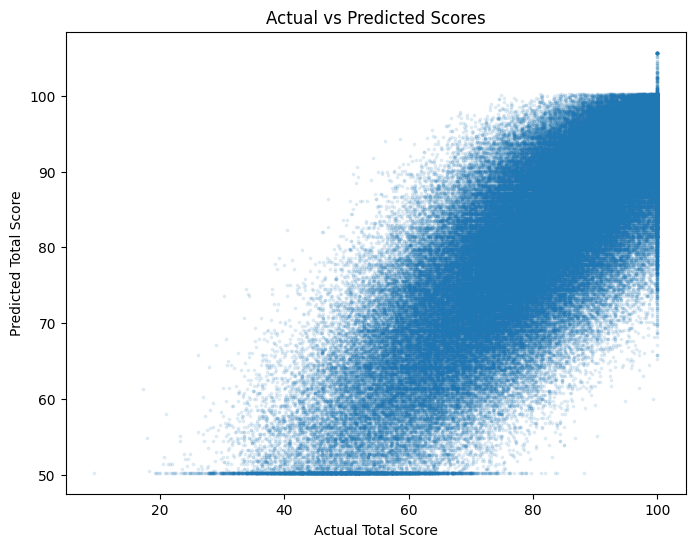

In [63]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_final,
    s=3,
    alpha=0.1
)

plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")
plt.title("Actual vs Predicted Scores")

plt.show()

## Save the model

In [64]:
import joblib

In [65]:
joblib.dump(poly_final, "polynomial_features.pkl")
joblib.dump(final_model, "student_score_polynomial_model.pkl")

['student_score_polynomial_model.pkl']